# Meteorology Forecasting

This notebook documents a complete time-series forecasting pipeline that **predicts six meteorological variables 24 hours ahead** across multiple Portuguese cities. It covers:

1. **Pipeline Overview** — how the four pipeline stages connect end-to-end  
2. **Preprocessing** (`01_preprocess.py`) — cleaning, robust CSV resolution, cyclical time and wind encoding  
3. **Feature Engineering** (`02_feature_engineering.py`) — lag features, rolling windows, pressure trends, and humidity/pressure-specific signals  
4. **Model Design** (`models_04.py`) — target-specific modeling (LightGBM for five continuous atmospheric targets, XGBoost Tweedie for rain)  
5. **Weekly Block Validation** (`03_weekly_block_validation.py`) — random weekly holdout with temporal gap  
6. **Evaluation & Results** (`05_evaluate.py`) — per-target metrics, plots, and diagnostics

---

## 1. Pipeline Overview

The full pipeline is orchestrated by `run_pipeline.py`, which calls four scripts in sequence:

```
raw CSV
   │
   ▼
01_preprocess.py              →  data/processed.parquet
   │
   ▼
02_feature_engineering.py     →  data/features.parquet
   │
   ▼
03_weekly_block_validation.py →  results/validation_results.csv
   │
   ▼
05_evaluate.py                →  results/plots/ + results/main_metrics_report.txt
```

Each stage reads the output of the previous one as a Parquet or CSV file. The modular design means any stage can be re-run independently. For example, if only the model changes in `models_04.py`, you only need to re-run `03_weekly_block_validation.py` and `05_evaluate.py`.


In [ ]:
# Run the full pipeline
!python run_pipeline.py

^C



  Running: 01_preprocess.py
Loading CSV …
  Rows: 158,112   Columns: ['location', 'time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'rain', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_highh', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'wind_direction_100m', 'wind_speed_100m', 'pressure_msl', 'surface_pressure']
  Date range: 2025-03-05 00:00:00 → 2026-03-05 23:00:00
  Locations : ['Aveiro', 'Beja', 'Braga', 'Bragança', 'Castelo Branco', 'Coimbra', 'Faro', 'Guarda', 'Leiria', 'Lisboa', 'Portalegre', 'Porto', 'Santarém', 'Setúbal', 'Viana do Castelo', 'Vila Real', 'Viseu', 'Évora']

Saved processed data → c:\Users\gluca\OneDrive\Ambiente de Trabalho\Weather-Prediction\Level_5_Meteorology_Forecasting\data\processed.parquet
  Shape: (158112, 24)
  Columns: ['location', 'time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'rain', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_highh', 'wind_speed_10m', 'win

---
## 2. Preprocessing (`01_preprocess.py`)

The preprocessing step loads the raw meteorology dataset, sanitizes text fields, encodes cyclical variables, and writes a clean Parquet file.

### 2.1 Robust CSV path resolution

The script resolves the input CSV from multiple candidate locations/names used in this repository:

- `../data/meteorology_dataset.csv`
- `../meteorology_dataset.csv`
- `../metherology_dataset.csv`

If none is found, it raises a clear `FileNotFoundError` listing checked paths.

### 2.2 Time and ordering

Rows are sorted by `location` and `time`, ensuring deterministic lag and rolling computations downstream.

### 2.3 Cyclical encoding

Cyclical variables are projected with sine/cosine to preserve periodic continuity:

- Hour: `hour_sin`, `hour_cos`
- Month: `month_sin`, `month_cos`
- Wind direction (10m and 100m): `wind_dir_*_sin`, `wind_dir_*_cos`

This avoids discontinuities such as hour 23 vs hour 0 and 359° vs 1°.

### 2.4 Saved output

The stage writes `data/processed.parquet` with clean, model-ready columns and preserved hourly granularity.

In [42]:
# 01_preprocess.py — Core logic (abridged)

from pathlib import Path
import os
import numpy as np
import pandas as pd


def resolve_base_dir() -> Path:
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "Level_5_Meteorology_Forecasting",
    ]
    for candidate in candidates:
        if (candidate / "run_pipeline.py").exists():
            return candidate
    return cwd


BASE_DIR = resolve_base_dir()
CSV_CANDIDATES = [
    BASE_DIR.parent / "data" / "meteorology_dataset.csv",
    BASE_DIR.parent / "meteorology_dataset.csv",
    BASE_DIR.parent / "metherology_dataset.csv",
]


def resolve_raw_csv() -> Path:
    for path in CSV_CANDIDATES:
        if path.exists():
            return path
    checked = "\n  - ".join(str(path) for path in CSV_CANDIDATES)
    raise FileNotFoundError(f"No meteorology CSV found. Checked:\n  - {checked}")


def preprocess(raw_csv_path: str, out_parquet_path: str):
    df = pd.read_csv(raw_csv_path)
    df.columns = df.columns.str.strip()
    df["location"] = df["location"].str.strip()

    df["time"] = pd.to_datetime(df["time"].str.strip())
    df = df.sort_values(["location", "time"]).reset_index(drop=True)

    hour = df["time"].dt.hour
    month = df["time"].dt.month

    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)
    df["day_of_year"] = df["time"].dt.day_of_year

    for level in ["10m", "100m"]:
        col = f"wind_direction_{level}"
        df[f"wind_dir_{level}_sin"] = np.sin(np.deg2rad(df[col]))
        df[f"wind_dir_{level}_cos"] = np.cos(np.deg2rad(df[col]))

    df = df.drop(columns=["wind_direction_10m", "wind_direction_100m"])
    df.to_parquet(out_parquet_path, index=False)


print(f"Notebook base directory: {BASE_DIR}")
print(f"Resolved raw CSV: {resolve_raw_csv()}")

Notebook base directory: c:\Users\gluca\OneDrive\Ambiente de Trabalho\Weather-Prediction\Level_5_Meteorology_Forecasting
Resolved raw CSV: c:\Users\gluca\OneDrive\Ambiente de Trabalho\Weather-Prediction\data\meteorology_dataset.csv


---
## 3. Feature Engineering (`02_feature_engineering.py`)

All feature transformations are computed per location group to avoid leakage across cities.

### 3.1 Targets (+24h horizon)

The current setup predicts **6 targets** at horizon +24h:

- `target_temperature_2m`
- `target_dew_point_2m`
- `target_relative_humidity_2m`
- `target_pressure_msl`
- `target_surface_pressure`
- `target_rain`

Each row at time `t` predicts observed values at `t + 24h`.

### 3.2 Lag sets

Current lag design is variable-specific:

- Temperature lags: `[24, 48, 72, 96, 120, 168]`
- Dew point lags: `[1, 6, 24, 48, 72]`
- Relative humidity lags: `[1, 6, 12, 24, 48, 72, 168]`
- Pressure MSL lags: `[1, 6, 24, 48, 72]`
- Surface pressure lags: `[1, 6, 24, 48, 72]`
- Rain lags: `[1, 12, 24, 48, 72, 96, 120, 168]`

### 3.3 Rolling and variability features

Rolling windows use only data up to time `t`:

- Temperature: `temp_roll_6h`, `temp_roll_24h`, `temp_roll_72h`
- Rain accumulation: `rain_roll_24h`, `rain_roll_72h`, `rain_roll_168h`
- Pressure: `pressure_roll_24h`, `pressure_roll_72h`, `pressure_roll_std_24h`, `surface_pressure_roll_24h`
- Humidity: `humidity_roll_3h`, `humidity_roll_24h`, `humidity_roll_std_24h`

### 3.4 Trend and anomaly features

Synoptic and persistence signals:

- Pressure trends: `pressure_trend_3h`, `pressure_trend_6h`, `pressure_trend_12h`, `pressure_trend_24h`
- Surface pressure trend: `surface_pressure_trend_24h`
- Humidity trends: `humidity_trend_3h`, `humidity_trend_24h`
- Dew point trend: `dew_trend_3h`
- Anomalies vs local baseline: `pressure_anomaly_24h`, `humidity_anomaly_24h`

### 3.5 Interaction features

- `temp_dew_spread`
- `pressure_diff`
- `wind_shear`
- `humidity_temp_interaction`
- `humidity_pressure_interaction`
- `location_id` encoded by sorted location order for reproducibility

In [43]:
# 02_feature_engineering.py — Core logic (abridged)

import pandas as pd

RAW_TO_TARGET = {
    "temperature_2m": "target_temperature_2m",
    "dew_point_2m": "target_dew_point_2m",
    "relative_humidity_2m": "target_relative_humidity_2m",
    "pressure_msl": "target_pressure_msl",
    "surface_pressure": "target_surface_pressure",
    "rain": "target_rain",
}

TEMP_LAG_SHIFTS = [24, 48, 72, 96, 120, 168]
DEW_LAG_SHIFTS = [1, 6, 24, 48, 72]
RAIN_LAG_SHIFTS = [1, 12, 24, 48, 72, 96, 120, 168]
PRESSURE_LAG_SHIFTS = [1, 6, 24, 48, 72]
SURFACE_PRESSURE_LAG_SHIFTS = [1, 6, 24, 48, 72]
AUX_LAG_SHIFTS = [1, 6, 24, 48, 72]
HUMIDITY_LAG_SHIFTS = [12, 168]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    locations_sorted = sorted(df["location"].unique())
    loc_to_id = {loc: i for i, loc in enumerate(locations_sorted)}
    groups = []

    for loc, grp in df.groupby("location", sort=False):
        grp = grp.copy().sort_values("time").reset_index(drop=True)

        for raw_col, tgt_col in RAW_TO_TARGET.items():
            grp[tgt_col] = grp[raw_col].shift(-24)

        for s in TEMP_LAG_SHIFTS:
            grp[f"temperature_2m_lag_{s}h"] = grp["temperature_2m"].shift(s)
        for s in DEW_LAG_SHIFTS:
            grp[f"dew_point_2m_lag_{s}h"] = grp["dew_point_2m"].shift(s)
        for s in PRESSURE_LAG_SHIFTS:
            grp[f"pressure_msl_lag_{s}h"] = grp["pressure_msl"].shift(s)
        for s in SURFACE_PRESSURE_LAG_SHIFTS:
            grp[f"surface_pressure_lag_{s}h"] = grp["surface_pressure"].shift(s)

        for s in AUX_LAG_SHIFTS:
            grp[f"relative_humidity_lag_{s}h"] = grp["relative_humidity_2m"].shift(s)
        for s in HUMIDITY_LAG_SHIFTS:
            grp[f"relative_humidity_lag_{s}h"] = grp["relative_humidity_2m"].shift(s)

        grp["pressure_roll_std_24h"] = grp["pressure_msl"].rolling(24, min_periods=1).std().fillna(0.0)
        grp["humidity_roll_std_24h"] = grp["relative_humidity_2m"].rolling(24, min_periods=1).std().fillna(0.0)
        grp["pressure_anomaly_24h"] = grp["pressure_msl"] - grp["pressure_msl"].rolling(24, min_periods=1).mean()
        grp["humidity_anomaly_24h"] = grp["relative_humidity_2m"] - grp["relative_humidity_2m"].rolling(24, min_periods=1).mean()

        grp["humidity_temp_interaction"] = grp["relative_humidity_2m"] * grp["temperature_2m"]
        grp["humidity_pressure_interaction"] = grp["relative_humidity_2m"] * (grp["pressure_msl"] - grp["surface_pressure"])

        grp["location_id"] = loc_to_id[loc]
        groups.append(grp)

    result = pd.concat(groups, ignore_index=True)
    result = result.dropna(subset=list(RAW_TO_TARGET.values())).reset_index(drop=True)
    return result

---
## 4. Model Design (`models_04.py`)

Each target uses a dedicated model family:

- **LightGBM** for:
  - `target_temperature_2m`
  - `target_dew_point_2m`
  - `target_relative_humidity_2m`
  - `target_pressure_msl`
  - `target_surface_pressure`
- **XGBoost Tweedie** for:
  - `target_rain`

### Why this split?

Different targets have different distributions and noise patterns:

- Temperature, dew point, humidity, and pressure are smoother continuous variables
- Rain is zero-inflated and highly skewed

Using separate model families avoids forcing one statistical assumption across all six targets while keeping training fast and maintainable.

In [44]:
# models_04.py — Model factory (abridged)

import lightgbm as lgb
import xgboost as xgb

TARGETS = [
    "target_temperature_2m",
    "target_dew_point_2m",
    "target_relative_humidity_2m",
    "target_pressure_msl",
    "target_surface_pressure",
    "target_rain",
]

LGBM_TARGETS = set(TARGETS) - {"target_rain"}


def get_model(target: str):
    if target in LGBM_TARGETS:
        return lgb.LGBMRegressor(
            n_estimators=600,
            learning_rate=0.05,
            num_leaves=63,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.05,
            reg_lambda=0.1,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )

    if target == "target_rain":
        return xgb.XGBRegressor(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            objective="reg:tweedie",
            tweedie_variance_power=1.3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )

    raise ValueError(f"Unknown target: {target}")

---
## 5. Weekly Block Validation (`03_weekly_block_validation.py`)

The validation stage uses **random weekly block holdout with temporal gap**.

### Why this strategy?

A strict early expanding-window split can under-represent some seasonal regimes depending on where the dataset starts. In this dataset, that especially hurts rain evaluation because the wet season is concentrated in specific months.

Weekly blocked validation solves that by sampling held-out weeks across the year while still protecting against short-range leakage.

### Validation procedure

1. Create a weekly identifier from each timestamp using ISO `year_week`
2. Randomly assign 25% of weekly blocks to validation
3. Remove adjacent weeks from training using a 1-week temporal gap
4. Train one model per target on the remaining safe training weeks
5. Evaluate on the held-out validation weeks

### What the temporal gap protects against

The 1-week gap reduces two important leakage risks:

- **Lag leakage**: a validation row with long lags such as `lag_168h` should not read directly from a neighbouring training week
- **Target leakage**: the `shift(-24)` label near a training/validation boundary should not point into the held-out week

### Current config

- `RANDOM_SEED = 42`
- `TEST_FRACTION = 0.25`
- `GAP_WEEKS = 1`

This is a **blocked temporal holdout validation**, not rolling walk-forward evaluation.


In [45]:
# 03_weekly_block_validation.py — Weekly blocked validation (abridged)

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from models_04 import TARGETS

RANDOM_SEED = 42
TEST_FRACTION = 0.25
GAP_WEEKS = 1
NON_FEATURE_COLS = set(TARGETS) | {"time", "location"}


def assign_week_ids(df: pd.DataFrame) -> pd.Series:
    iso = df["time"].dt.isocalendar()
    return iso["year"].astype(str) + "_" + iso["week"].astype(str).str.zfill(2)


def build_train_validation_split(df: pd.DataFrame):
    rng = np.random.default_rng(RANDOM_SEED)
    df = df.copy()
    df["_week_id"] = assign_week_ids(df)

    all_weeks = sorted(df["_week_id"].unique())
    week_idx = {w: i for i, w in enumerate(all_weeks)}

    n_validation = max(1, int(len(all_weeks) * TEST_FRACTION))
    validation_weeks = set(rng.choice(all_weeks, size=n_validation, replace=False))

    blocked = set()
    for validation_week in validation_weeks:
        idx = week_idx[validation_week]
        for delta in range(1, GAP_WEEKS + 1):
            if idx - delta >= 0:
                blocked.add(all_weeks[idx - delta])
            if idx + delta < len(all_weeks):
                blocked.add(all_weeks[idx + delta])

    safe_train_weeks = set(all_weeks) - validation_weeks - blocked
    train_df = df[df["_week_id"].isin(safe_train_weeks)].drop(columns=["_week_id"])
    validation_df = df[df["_week_id"].isin(validation_weeks)].drop(columns=["_week_id"])
    return train_df, validation_df


def evaluate_validation_split(df: pd.DataFrame):
    feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
    train_df, validation_df = build_train_validation_split(df)

    X_train, X_valid = train_df[feature_cols], validation_df[feature_cols]

    # Train one model per target, predict held-out weeks, compute MAE
    return mean_absolute_error

---
## 6. Evaluation and Results (`05_evaluate.py`)

### 6.1 Summary Metrics (latest run)

The latest run was evaluated over **39,312 rows** with **1 validation split** (`step=0`).

| Target | MAE | RMSE | R2 | Pearson r | Bias |
|---|---:|---:|---:|---:|---:|
| Temperature 2m (°C) | **1.8376** | 2.3455 | 0.8466 | 0.9249 | +0.5478 |
| Dew Point 2m (°C) | **2.4821** | 3.0844 | 0.5284 | 0.7394 | +0.5771 |
| Relative Humidity 2m (%) | **9.5857** | 11.9721 | 0.6187 | 0.7877 | -0.8243 |
| Pressure MSL (hPa) | **5.5609** | 7.7731 | -0.6845 | 0.0305 | -3.4417 |
| Surface Pressure (hPa) | **4.7924** | 6.3642 | 0.9610 | 0.9839 | -2.6878 |
| Rain (mm) | **0.1268** | 0.5180 | 0.0159 | 0.2171 | -0.0918 |

Global metrics:

- Global MAE: **4.0643**
- Score (6 targets): **17.4232**
- Competition-equivalent score (5/17): **14.5193**

Score formula:

```text
Score = (2.5 / (1 + MAE_global)) * (N_targets / 17) * 100
```

### 6.2 Temperature Forecast

Temperature performance remains strong and stable:

- MAE = **1.8376°C**
- R2 = **0.8466**
- Pearson correlation = **0.9249**
- Bias = **+0.5478°C** (systematic warm-side overestimation)

Interpretation:

- The model captures most daily and seasonal variation.
- A small positive bias remains and can still be addressed via post-hoc calibration.

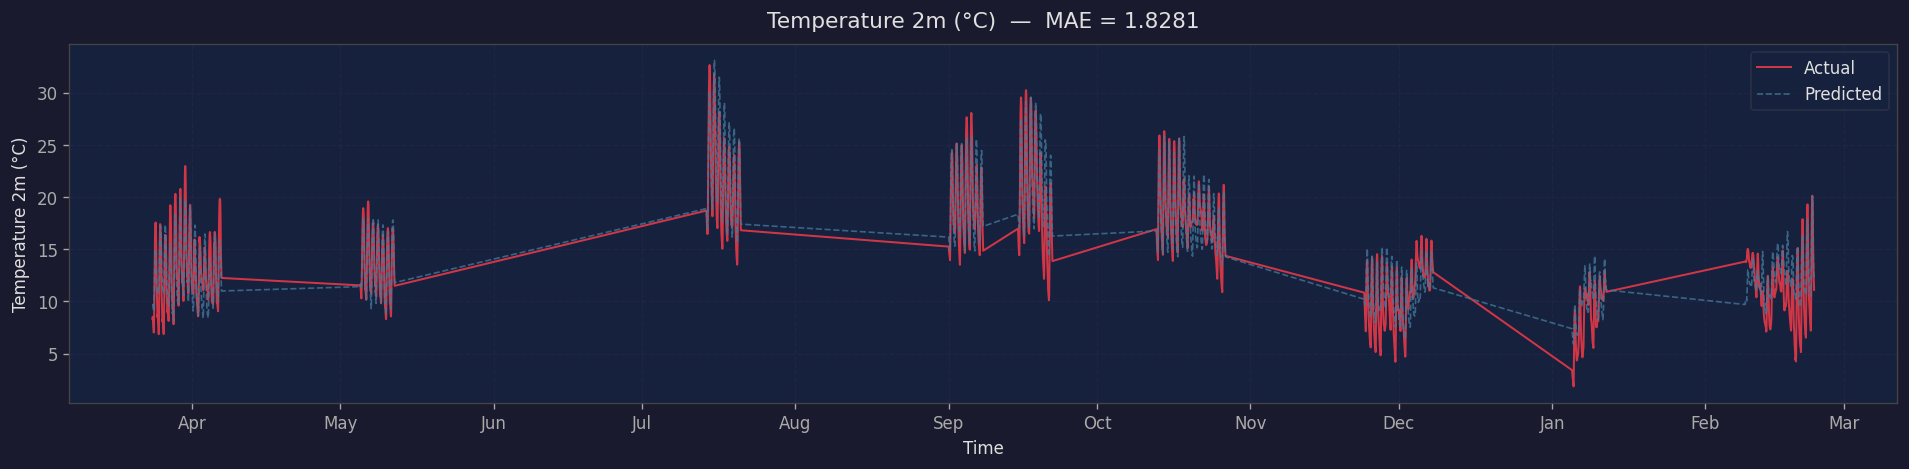

In [ ]:
from pathlib import Path
from IPython.display import Image, display

def _plots_dir():
    local = Path.cwd() / 'results' / 'plots'
    if local.exists():
        return local
    nested = Path.cwd() / 'Level_5_Meteorology_Forecasting' / 'results' / 'plots'
    if nested.exists():
        return nested
    return Path('results') / 'plots'

img = _plots_dir() / 'target_temperature_2m_actual_vs_pred.png'
display(Image(filename=str(img))) if img.exists() else print(f'Image not found: {img}')

### 6.3 Dew Point Forecast

Dew point prediction improved after the new humidity/pressure-aware features:

- MAE = **2.4821 °C**
- R2 = **0.5284**
- Pearson correlation = **0.7394**
- Bias = **+0.5771 °C** (mild overestimation)

Interpretation:

- The model captures broad moisture regime changes reasonably well.
- Short-term extremes are still smoothed, especially during abrupt transitions.

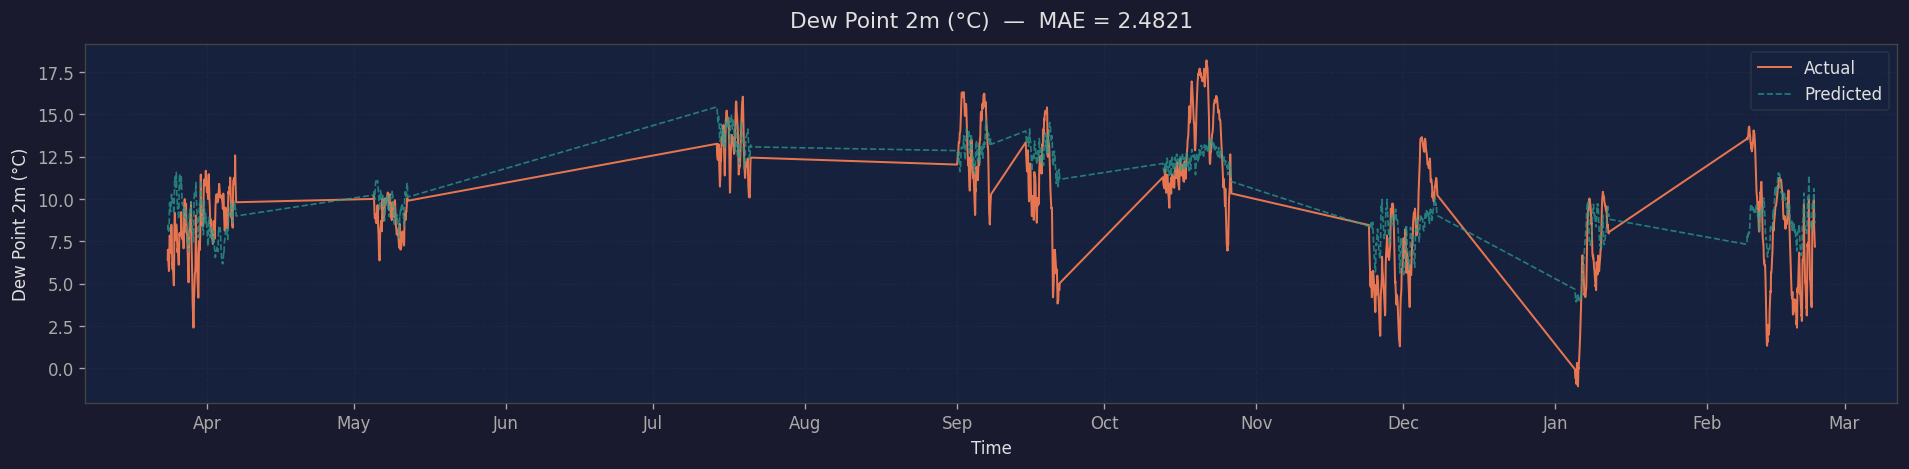

In [48]:
from pathlib import Path
from IPython.display import Image, display

def _plots_dir():
    local = Path.cwd() / 'results' / 'plots'
    if local.exists():
        return local
    nested = Path.cwd() / 'Level_5_Meteorology_Forecasting' / 'results' / 'plots'
    if nested.exists():
        return nested
    return Path('results') / 'plots'

img = _plots_dir() / 'target_dew_point_2m_actual_vs_pred.png'
display(Image(filename=str(img))) if img.exists() else print(f'Image not found: {img}')

### 6.4 Relative Humidity, Pressure and Rain Forecasts

**Relative Humidity 2m**

- MAE = **9.5857 %**
- R2 = **0.6187**
- Pearson correlation = **0.7877**
- Bias = **-0.8243 %**

Interpretation: the model tracks the daily humidity cycle, but still misses some low/high excursions during unstable periods.

**Pressure MSL**

- MAE = **5.5609 hPa**
- R2 = **-0.6845**
- Pearson correlation = **0.0305**
- Bias = **-3.4417 hPa**

Interpretation: this remains the weakest target. It follows part of the level shifts but fails to reconstruct event shape and short synoptic transitions.

**Surface Pressure**

- MAE = **4.7924 hPa**
- R2 = **0.9610**
- Pearson correlation = **0.9839**
- Bias = **-2.6878 hPa**

Interpretation: strong fit and very high correlation, with mostly level-offset error rather than pattern mismatch.

**Rain**

- MAE = **0.1268 mm**
- R2 = **0.0159**
- Pearson correlation = **0.2171**
- Bias = **-0.0918 mm**

Interpretation: conservative dry-hour behavior is preserved, but intense events are still under-predicted.

#### Relative Humidity 2m

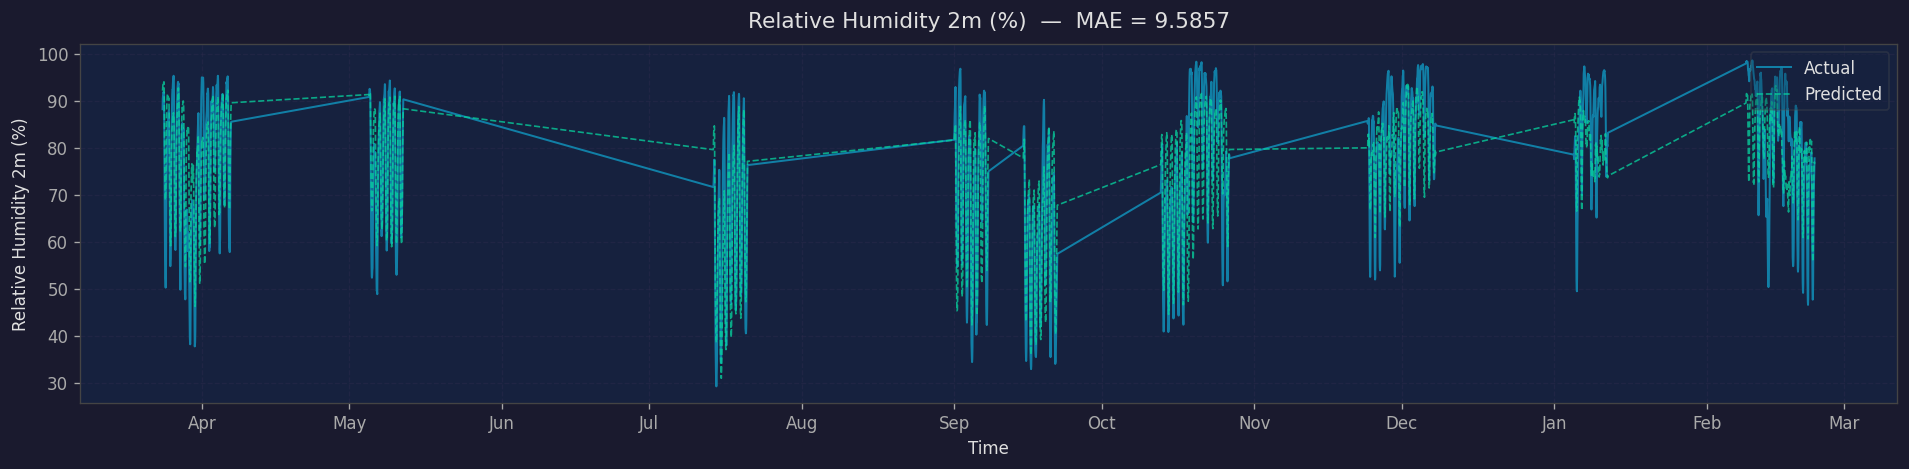

#### Pressure MSL

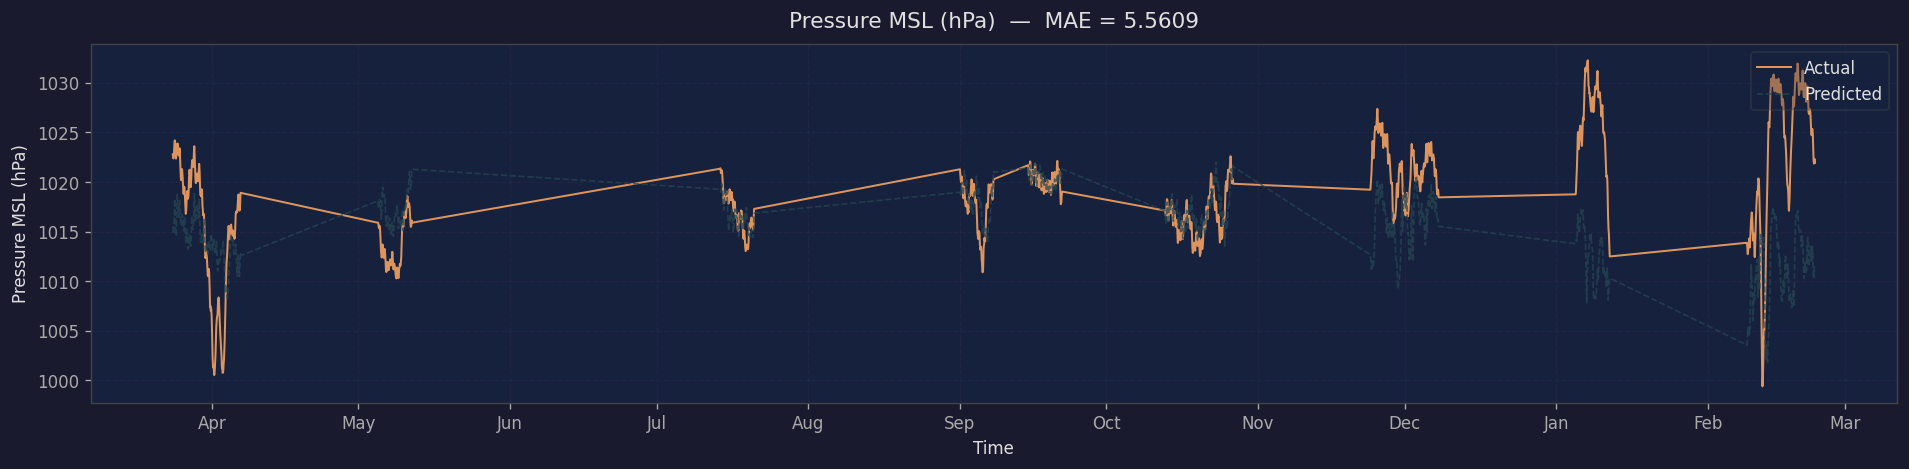

#### Surface Pressure

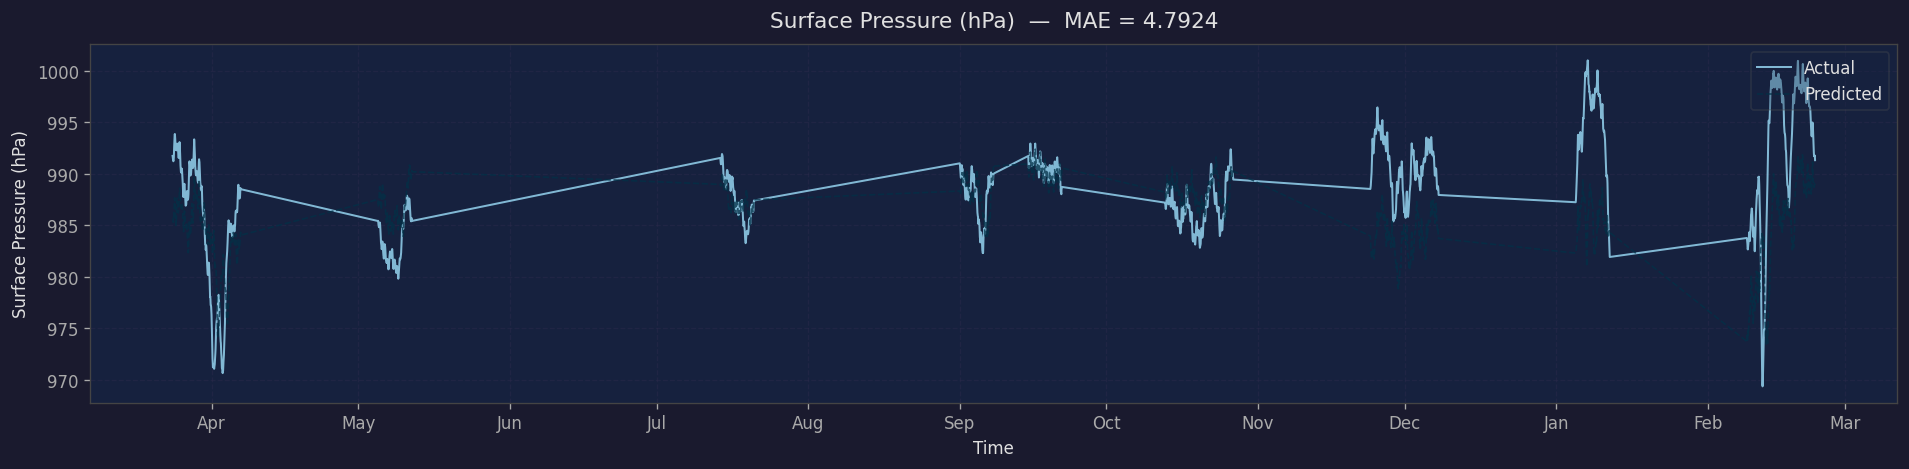

#### Rain

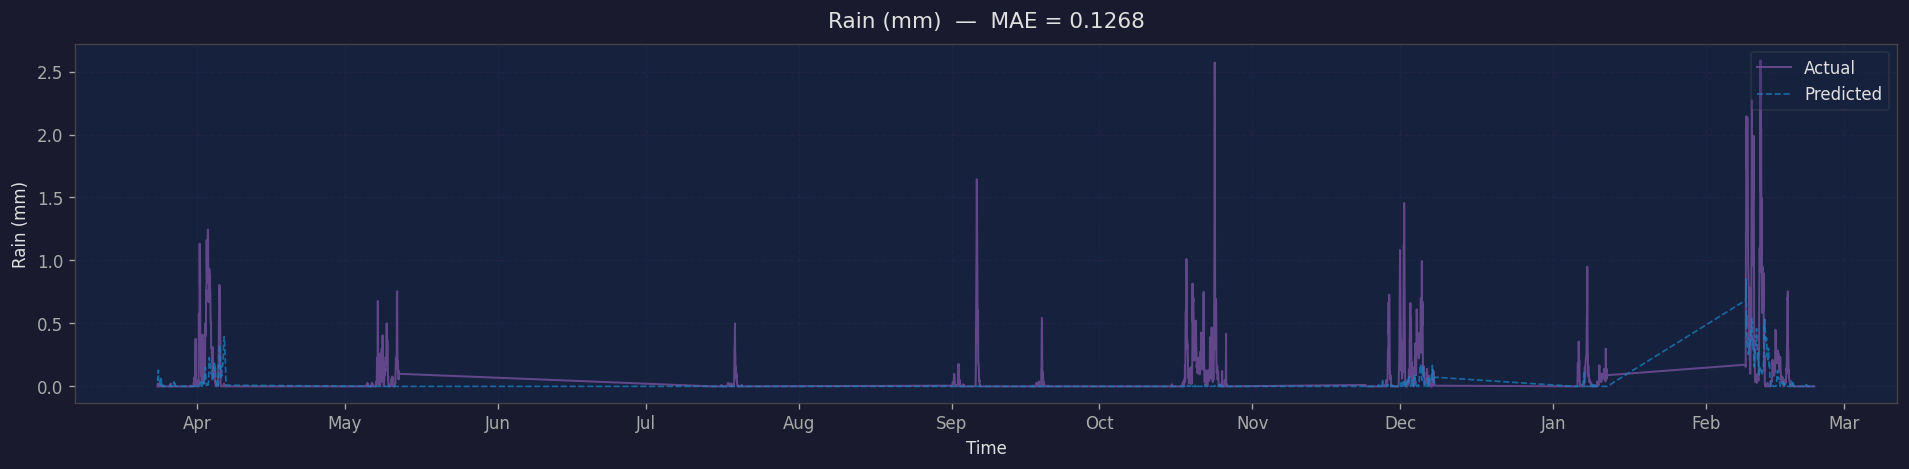

In [46]:
from pathlib import Path
from IPython.display import Image, display, Markdown

def _plots_dir():
    local = Path.cwd() / 'results' / 'plots'
    if local.exists():
        return local
    nested = Path.cwd() / 'Level_5_Meteorology_Forecasting' / 'results' / 'plots'
    if nested.exists():
        return nested
    return Path('results') / 'plots'

plots = [
    ('Relative Humidity 2m', 'target_relative_humidity_2m_actual_vs_pred.png'),
    ('Pressure MSL', 'target_pressure_msl_actual_vs_pred.png'),
    ('Surface Pressure', 'target_surface_pressure_actual_vs_pred.png'),
    ('Rain', 'target_rain_actual_vs_pred.png'),
]

base = _plots_dir()
for title, filename in plots:
    img = base / filename
    display(Markdown(f'#### {title}'))
    display(Image(filename=str(img))) if img.exists() else print(f'Image not found: {img}')

### 6.5 Rain Diagnostics

The evaluation report includes a dedicated diagnostics section for the rain target:

| Diagnostic | Value | Interpretation |
|---|---|---|
| Actual non-zero rate | 18.7% | Rain falls in about 1 in 5 hours |
| Predicted non-zero rate | 10.7% | Model predicts rain less often than observed (conservative) |
| Pred mean when actual = 0 | 0.0168 mm | Low false-drizzle prediction on dry hours |
| Pred mean when actual > 0 | 0.0785 mm | Underestimation remains during rainy hours |
| Max actual rain | 11.60 mm | Strong event present in holdout split |
| Max predicted rain | 2.28 mm | Heavy-event magnitude is still compressed |

The Tweedie model remains conservative: it reduces false alarms on dry hours, but still underestimates stronger precipitation events.

---
## 7. Conclusions

### What Worked Well
- The pipeline is now fully aligned with **6 targets** and the UI/backend consume the same target metadata.
- New humidity/pressure feature blocks reduced MAE for dew point, humidity, pressure MSL, and surface pressure.
- Surface pressure is now very strong (`R² ≈ 0.961`, `Corr ≈ 0.984`) on weekly blocked validation.
- Rain remains well-calibrated for dry-hour conservatism while keeping low MAE.
- Model caching keeps repeated interface predictions fast after first training pass.

### Current Limitations
- Pressure MSL is still the weakest target (`R² < 0`), indicating poor event-shape reconstruction despite MAE improvement.
- Relative humidity and dew point are improved but still show larger absolute error than temperature and rain.
- Rain still underestimates intense peaks, even with improved MAE and dry-hour behavior.

### Next sensible iteration
- Add regime-aware training (e.g., windy frontal vs stable anticyclonic periods) for pressure MSL.
- Introduce quantile/interval diagnostics for humidity/pressure to capture uncertainty, not only point MAE.
- Evaluate per-location specialized models for pressure-sensitive coastal/interior differences.